In [10]:
from torchvision.datasets import DatasetFolder
from PIL import Image
import os
import configparser
import torch 
import scipy.stats
import csv
import numpy as np 
from torchvision import transforms
from torch.utils.data import DataLoader
from model import Network
from ut import GiveMeSampleSize, BalanceSet
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import plotly.io as pio
import configparser
from torcheval.metrics.functional import multiclass_f1_score
from torchvision.datasets import ImageFolder


In [3]:
#USATO FINO AD ORA
# Crea un oggetto ConfigParser
config = configparser.ConfigParser()

# Leggi il file di configurazione
config.read('/home/chiara/DataAUG/Classification/con.ini')

train_folder = config['AAA']['train_folder']

out_ss=len(os.listdir(train_folder))
in_ch=int(config['AAA']['in_ch'])
N_EPOCHS = int(config['AAA']['num_epoch'])
N = int(config['AAA']['N'])
BATCH_SIZE = int(config['AAA']['BATCH_SIZE'])
ss = int(config['AAA']['SS'])



##############################################################
##########################  TRAIN  ###########################
##########################  realDataOnly  ####################
##############################################################

#Data
test_folder = config['AAA']['test_folder']
transform =  transforms.Compose(
            [ transforms.ToTensor(),transforms.Grayscale(num_output_channels=1), transforms.Normalize((0.5), (1))])
#test = BalanceSet(root_path=test_folder, transform=transform, N = 753)
test = ImageFolder(root=test_folder, transform=transform)
test_loader = DataLoader(test, batch_size=BATCH_SIZE, num_workers=24)

label_mapping = {
    'Backdoor_attack': 0,
    'DDoS_HTTP_Flood_Attacks': 1,
    'NET': 2,
    'Port_Scanning_attack': 3,
    'Ransomware_attack': 4,#-- 
    'SQL_injection_attack': 5,
    'Uploading_attack': 6,#--
    'Vulnerability_scanner_attack': 7
}
print('data loaded')

data loaded


In [27]:
#path = '/home/chiara/DataAUG/Classification/MODELLI'
#path = '/home/chiara/DataAUG/Modelli_scelti_finali'
#path = '/home/chiara/DataAUG/Classification/MODELLI_final_0'
path = '/home/chiara/DataAUG/Classification/FINAL_MODEL'
#path = '/home/chiara/DataAUG/Tutti_result/MODELLI_final_NOOOOù'
#path = '/home/chiara/DataAUG/Tutti_result/Modelsss'

Models = [i for i in os.listdir(path) if i.endswith('.pth')]

Models

['GAN_10.pth',
 'GAN_80.pth',
 'DIFF_30.pth',
 'GAN_30.pth',
 'DIFF_60.pth',
 'DIFF_50.pth',
 'GAN_20.pth',
 'DIFF_80.pth',
 'GAN_50.pth',
 '16_with_dropout.pth',
 'DIFF_10.pth',
 'GAN_60.pth',
 'GAN_90.pth',
 'DIFF_20.pth']

In [ ]:
from sklearn.metrics import roc_auc_score

# Assuming y_true contains the true labels
# all_roc_auc contains the predicted probabilities for each class

# Calculate multi-class AUROC using One-vs-Rest strategy
auroc_score_ovr = roc_auc_score(y_true, all_roc_auc, multi_class='ovr', average='macro')

# Calculate multi-class AUROC using One-vs-One strategy
auroc_score_ovo = roc_auc_score(y_true, all_roc_auc, multi_class='ovo', average='macro')

print(f'Multi-class AUROC (OvR): {auroc_score_ovr}')
print(f'Multi-class AUROC (OvO): {auroc_score_ovo}')

In [22]:
from sklearn.metrics import roc_auc_score

#name = 'Diff. 30%'
#name = 'GAN 20%'
#name = ' No Synth. data'
#Mod = Models[0]
AUROC = []
for i in range(0,len(Models)):
    Mod = Models[i]
    path_tmp = os.path.join(path,Mod)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tmp_model = Network(1, out_ss, ss =ss, p = 0.2, up =0 ).to(device)

    tmp_model.load_state_dict(torch.load(path_tmp,  map_location=device))
    print(f'Model loaded {Mod}')
    tmp_model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            outputs = tmp_model(inputs, 0)
            # Thresholding
            predicted_classes = torch.argmax(outputs, dim=1)

            # Collect tensors arrays
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predicted_classes.cpu().numpy())

    # Calculate confusion matrix
    labels = list(label_mapping.values())
    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
    #print(conf_matrix)
    #print(classification_report(y_true, y_pred, labels=labels))
    print(f'F1: {multiclass_f1_score( torch.tensor(y_pred), torch.tensor(y_true), num_classes=8 )}')
    FP = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
    #print(f'False Positives for each class: {FP}')
    #a=classification_report(y_true, y_pred, labels=labels, output_dict=True)
    a = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=1)
    f1_scores = [a[f'{i}']['f1-score'] for i in range(0, 7)]
    #print(f'VAR f1 : {np.var(f1_scores)}')
    #print(f'Accuracy {a['accuracy']}')
    
    # Calculate multi-class AUROC using One-vs-Rest strategy
    auroc_score_ovr = roc_auc_score(y_true, all_roc_auc, multi_class='ovr', average='macro')

    # Calculate multi-class AUROC using One-vs-One strategy
    auroc_score_ovo = roc_auc_score(y_true, all_roc_auc, multi_class='ovo', average='macro')

    print(f'Multi-class AUROC (OvR): {auroc_score_ovr}')
    print(f'Multi-class AUROC (OvO): {auroc_score_ovo}')

Model loaded GAN_10.pth


KeyboardInterrupt: 

## Sankey

In [11]:
test_set = 'TOT'
for i in range(0,len(Models)):
    Mod = Models[i]
    path_tmp = os.path.join(path,Mod)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tmp_model = Network(1, out_ss, ss =ss, p = 0.2, up =0 ).to(device)

    tmp_model.load_state_dict(torch.load(path_tmp,  map_location=device))
    print(f'Model loaded {Mod}')
    tmp_model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            outputs = tmp_model(inputs, 0)
            # Thresholding
            predicted_classes = torch.argmax(outputs, dim=1)

            # Collect tensors arrays
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predicted_classes.cpu().numpy())
    # Calculate confusion matrix
    labels = list(label_mapping.values())
    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
    name = Mod
    # Dictionary for labels mapping
    labels_dict = {
        'Backdoor': 0,
        'DDoS Flood': 1,
        'Neutral': 2,
        'Port Scanning': 3,
        'Ransomware': 4,
        'SQL injection ': 5,
        'Uploading': 6,
        'Vulnerability Scanner': 7
    }

    # Extract labels from the dictionary
    labels = list(labels_dict.keys())

    # Number of classes
    num_classes = len(labels)

    # Generate source and target indices for the Sankey diagram
    source = []
    target = []
    value = []

    for i in range(num_classes):
        for j in range(num_classes):
            source.append(i)
            target.append(j + num_classes)
            value.append(conf_matrix[i][j])

    # Node labels (both input and output)
    node_labels = labels + labels

    # Define colors for correct and incorrect predictions
    incorrect_red = "rgba(213, 89, 51, 0.8)"
    correct_green = "rgba(122, 213, 179, 0.8)"

    # Assign colors based on whether the prediction is correct or incorrect
    link_colors = []
    for i in range(num_classes):
        for j in range(num_classes):
            if i == j:
                link_colors.append(correct_green)  # Correct prediction
            else:
                link_colors.append(incorrect_red)  # Incorrect prediction
    pastel_colors = ["#ff6a6a", "#ffd09a", "#fdff9a", "#a9ff95", "#88f5ff", "#98bfff", "#a294ff", "#ffadff"]

    # Create the Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        # orientation='v', 
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            #label=node_labels,
            label=[''] * len(node_labels),
            color=pastel_colors
    [:num_classes] * 2  # Using the first few colors for the nodes
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_colors,
        ))])


    fig.update_layout(
        title_text=f"{test_set} - Synth. data {name}",#
        font_size=25,
        height=600,  # Adjust height if needed for better display
        width=600,
        annotations=[
            dict(
                x=-.1,
                y=0.5,
                xref='paper',
                yref='paper',
                text='Actual Classes',
                showarrow=False,
                textangle=-90,
                font=dict(
                    size=20,
                    color='black'
                )
            ),
            dict(
                x=1.1,
                y=0.5,
                xref='paper',
                yref='paper',
                text='Predicted Classes',
                showarrow=False,
                textangle=90,
                font=dict(
                    size=20,
                    color='black'
                )
            )
        ]
    )
    pio.write_image(fig, f'/home/chiara/DataAUG/Classification/Sankey/Sankey_tot/{name}.png', width=1000, height=1000)




#fig.show()


Model loaded GAN_10.pth


KeyboardInterrupt: 

In [ ]:

# Initialize a list to store FP data
fp_data = []
tp_data = []

for i in range(len(Models)):
    Mod = Models[i]
    path_tmp = os.path.join(path, Mod)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tmp_model = Network(1, out_ss, ss=ss, p=0.2, up=0).to(device)
    tmp_model.load_state_dict(torch.load(path_tmp, map_location=device))
    print(f'Model loaded {Mod}')
    tmp_model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = tmp_model(inputs, 0)
            predicted_classes = torch.argmax(outputs, dim=1)

            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predicted_classes.cpu().numpy())

    labels = list(label_mapping.values())
    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
    print(f'F1: {multiclass_f1_score(torch.tensor(y_pred), torch.tensor(y_true), num_classes=8)}')
    FP = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
    TP =  np.diag(conf_matrix)
    print(f'False Positives for each class: {FP}')
    
    # Collect FP data for the current model
    fp_data.append([Mod] + FP.tolist())
    tp_data.append([Mod] + TP.tolist())

# Define the CSV file path
csv_file_path = 'Sankey/false_positives_TOT.csv'
sv_file_path = 'Sankey/True_positives_TOT.csv'

# Write FP data to CSV
with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    header = ['Model'] + [f'Class_{i}_FP' for i in range(len(FP))]
    writer.writerow(header)
    writer.writerows(fp_data)
    
with open(sv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    header = ['Model'] + [f'Class_{i}_FP' for i in range(len(FP))]
    writer.writerow(header)
    writer.writerows(fp_data)

print(f'False positives data has been saved to {sv_file_path}')


Model loaded 16_with_dropout_30DIFF.pth


F1: 0.9372342228889465
False Positives for each class: [  28   35    3 1422   12  178  356 1390]
Model loaded 16_with_dropout_50GAN.pth
F1: 0.9290584921836853
False Positives for each class: [ 104  294    0 1420   22 1543  408   79]
Model loaded 16_with_dropout_20DIFF_ch.pth
F1: 0.9437234401702881
False Positives for each class: [ 367  154    1 1396   15   15   63 1059]
Model loaded 16_with_dropout_50DIFF.pth
F1: 0.9289302229881287
False Positives for each class: [  69  101    2 1416   25   30  786 1448]
Model loaded 16_with_dropout_80DIFF.pth
F1: 0.911350667476654
False Positives for each class: [ 448  176    9 1269  593   75  300 1966]
Model loaded 16_with_dropout_80GAN.pth
F1: 0.8965024352073669
False Positives for each class: [ 769 1069    7 1579 1102  259  293  568]
Model loaded 16_with_dropout.pth
F1: 0.950395941734314
False Positives for each class: [ 189   91    2 1403   27    6  202  786]
Model loaded 16_with_dropout05_20GAN.pth
F1: 0.8960624933242798
False Positives for each 

## ROC

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
import os

# To store ROC curves for each model
all_fpr = []
all_tpr = []
all_roc_auc = []
all_y_true = []
all_y_score = []

for i in range(len(Models)):
    Mod = Models[i]
    path_tmp = os.path.join(path, Mod)
    device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tmp_model = Network(1, out_ss, ss=ss, p=0.2, up=0).to(device)
    tmp_model.load_state_dict(torch.load(path_tmp, map_location=device))
    print(f'Model loaded {Mod}')
    tmp_model.eval()
    y_true = []
    y_score = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = tmp_model(inputs, 0)
            y_true.extend(targets.cpu().numpy())
            y_score.extend(outputs.cpu().numpy())

    y_true_np = np.array(y_true)
    y_score_np = np.array(y_score)


    # Apply softmax function to the predicted scores
    all_y_score_np = np.exp(all_y_score_np) / np.sum(np.exp(all_y_score_np), axis=1, keepdims=True)

    # Calculate multi-class AUROC using One-vs-Rest strategy
    auroc_score_ovr = roc_auc_score(all_y_true_np, all_y_score_np, multi_class='ovr', average='macro')

    # Calculate multi-class AUROC using One-vs-One strategy
    auroc_score_ovo = roc_auc_score(all_y_true_np, all_y_score_np, multi_class='ovo', average='macro')

    print(f"Multi-class AUROC (OvR): {auroc_score_ovr:.4f}")
    print(f"Multi-class AUROC (OvO): {auroc_score_ovo:.4f}")


Model loaded GAN_10.pth


Multi-class AUROC (OvR): 0.9882
Multi-class AUROC (OvO): 0.9610
Model loaded GAN_80.pth
Multi-class AUROC (OvR): 0.9884
Multi-class AUROC (OvO): 0.9610
Model loaded DIFF_30.pth
Multi-class AUROC (OvR): 0.9884
Multi-class AUROC (OvO): 0.9610
Model loaded GAN_30.pth
Multi-class AUROC (OvR): 0.9883
Multi-class AUROC (OvO): 0.9610
Model loaded DIFF_60.pth
Multi-class AUROC (OvR): 0.9878
Multi-class AUROC (OvO): 0.9607
Model loaded DIFF_50.pth
Multi-class AUROC (OvR): 0.9874
Multi-class AUROC (OvO): 0.9605
Model loaded GAN_20.pth
Multi-class AUROC (OvR): 0.9871
Multi-class AUROC (OvO): 0.9603
Model loaded DIFF_80.pth
Multi-class AUROC (OvR): 0.9867
Multi-class AUROC (OvO): 0.9598
Model loaded GAN_50.pth
Multi-class AUROC (OvR): 0.9619
Multi-class AUROC (OvO): 0.9402
Model loaded 16_with_dropout.pth
Multi-class AUROC (OvR): 0.9551
Multi-class AUROC (OvO): 0.9210


RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

In [12]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from torch.utils.data import DataLoader


Model loaded GAN_10.pth


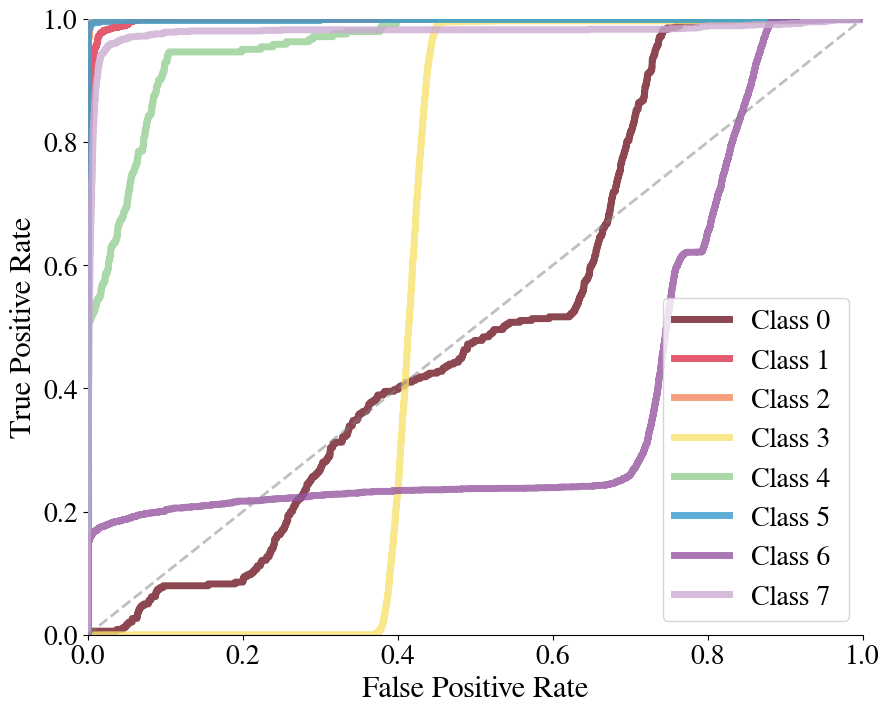

Model loaded GAN_80.pth


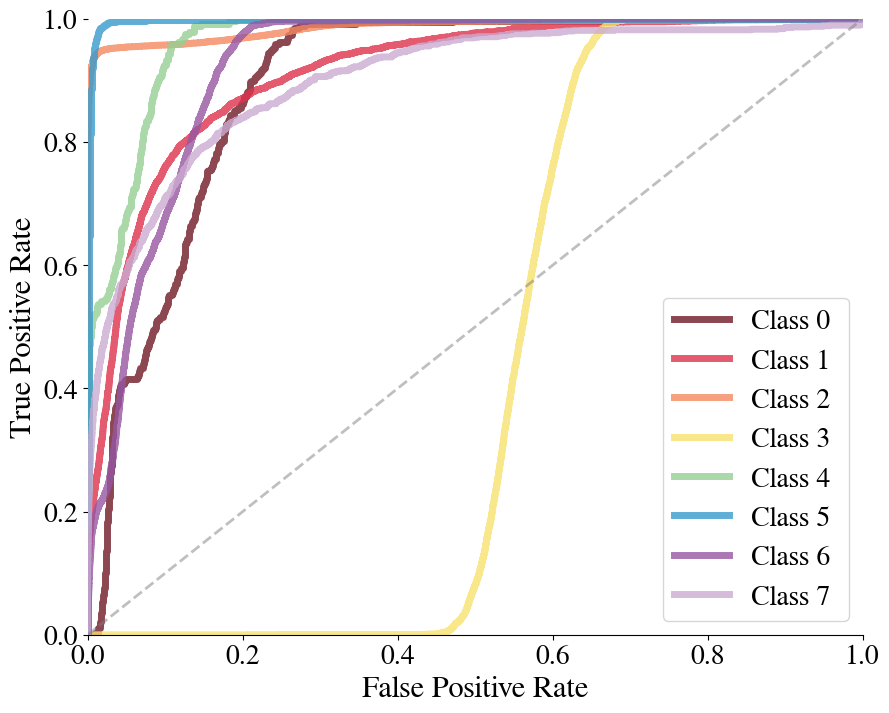

Model loaded DIFF_30.pth


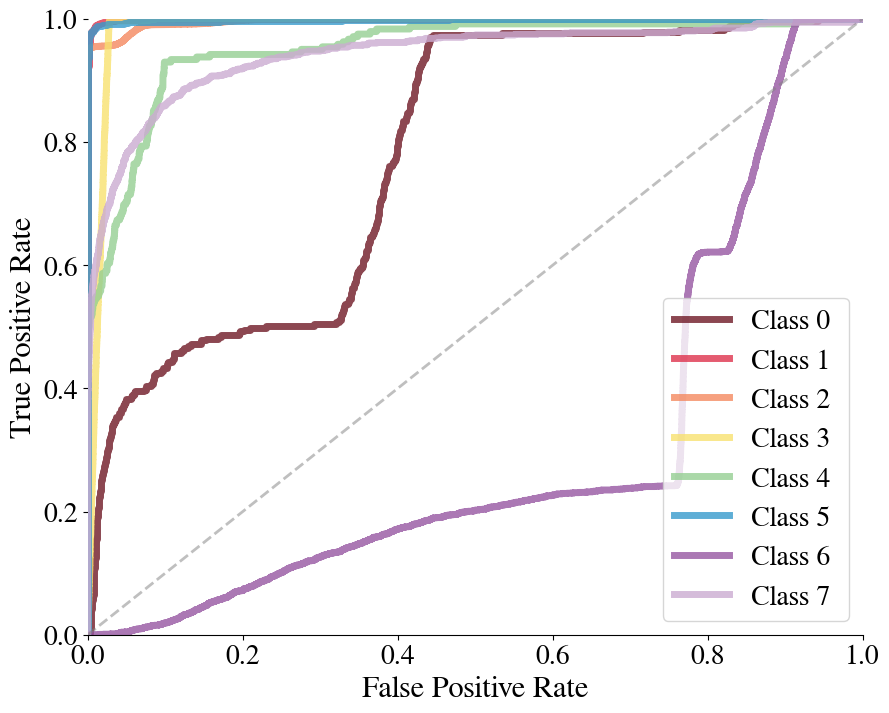

Model loaded GAN_30.pth


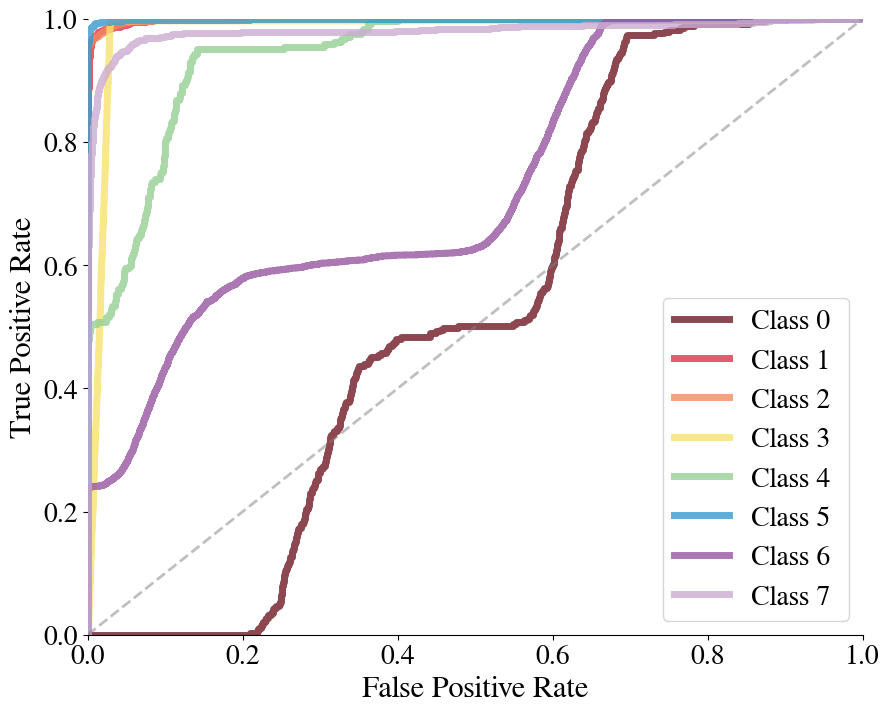

Model loaded DIFF_60.pth


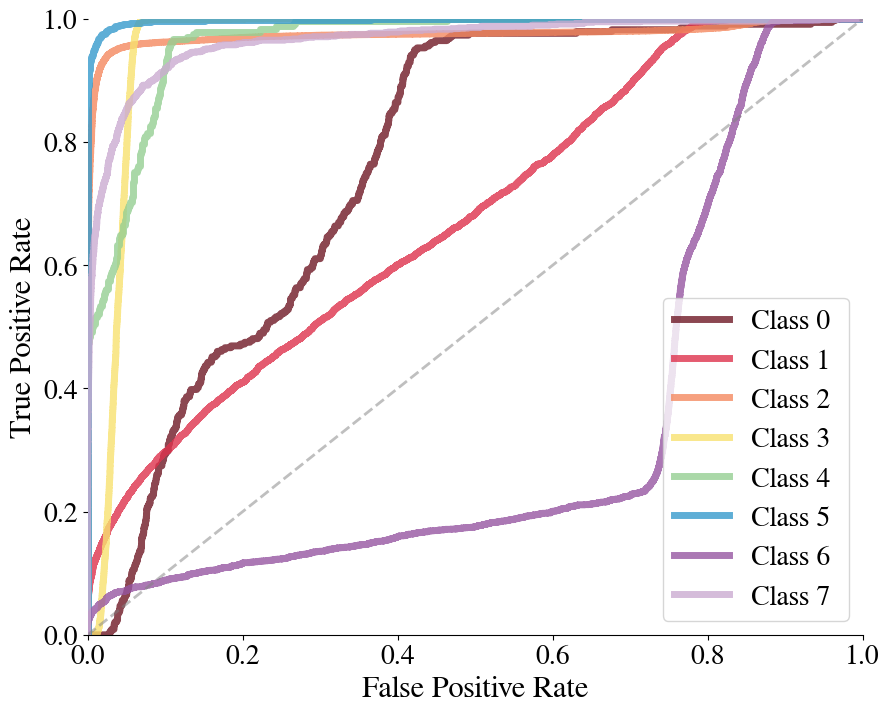

Model loaded DIFF_50.pth


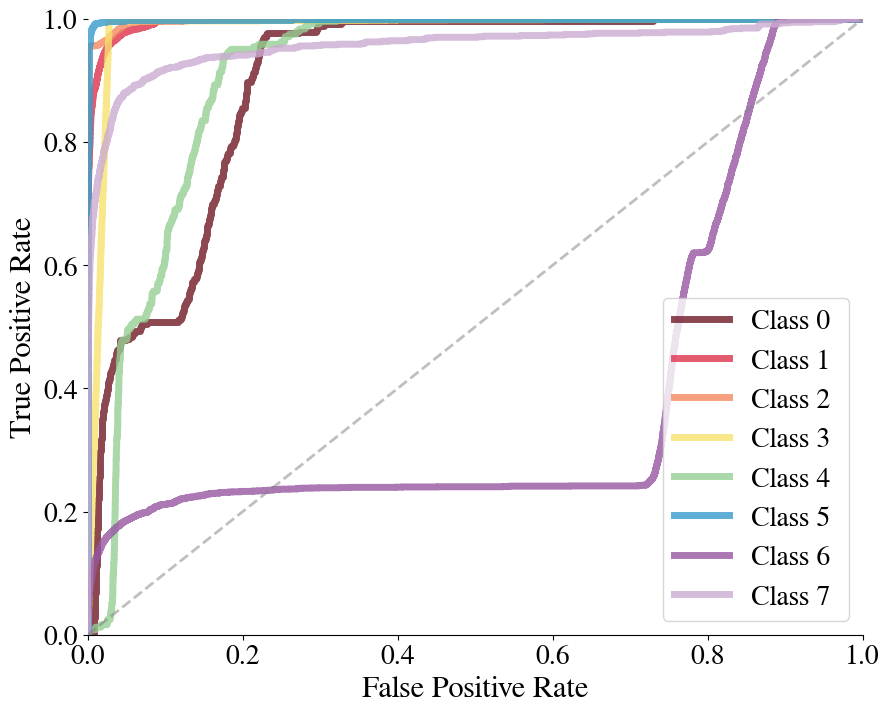

Model loaded GAN_20.pth


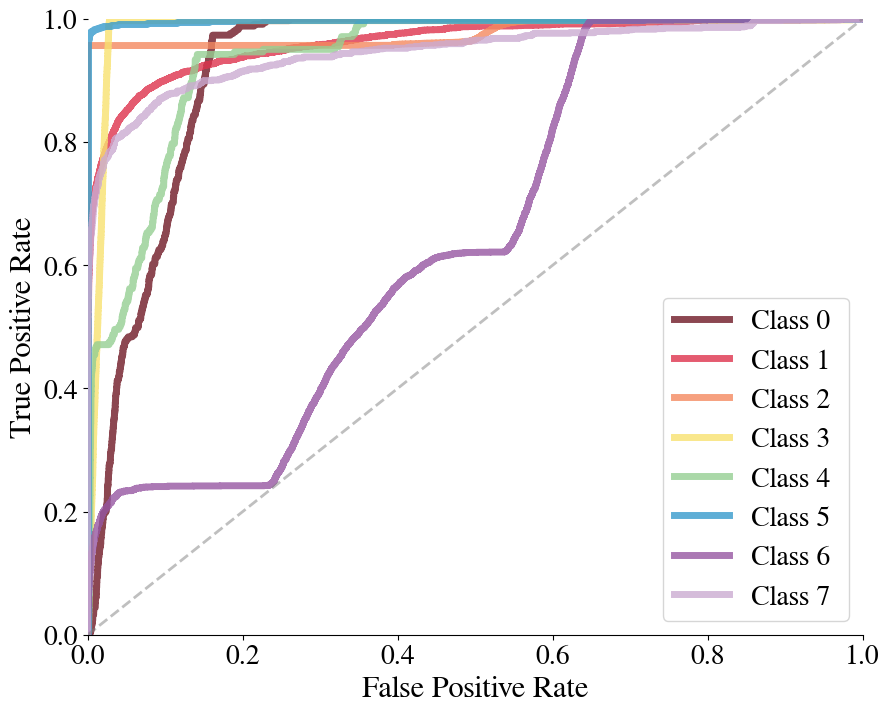

Model loaded DIFF_80.pth


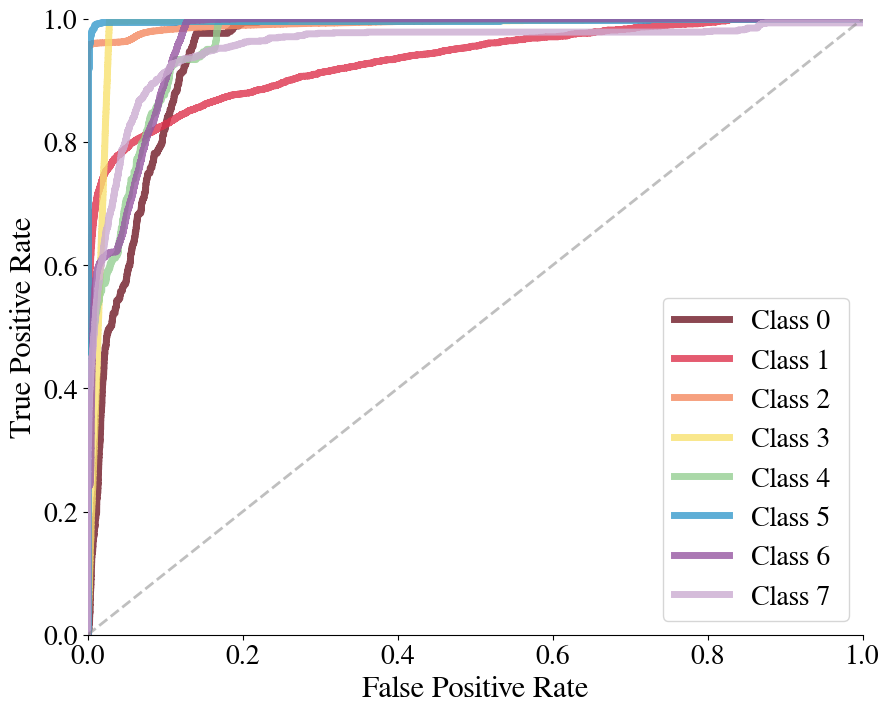

Model loaded GAN_50.pth


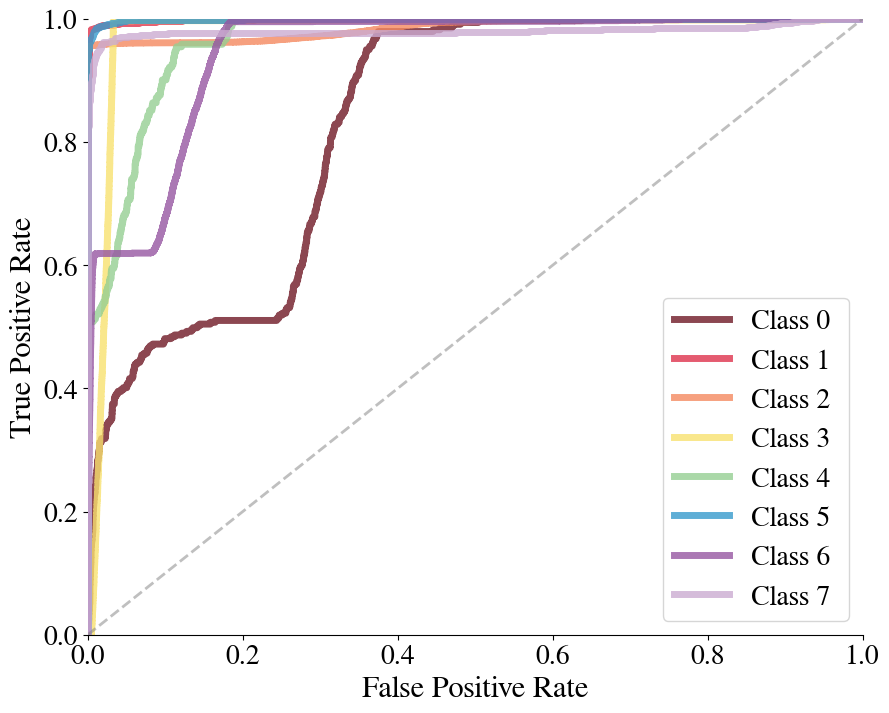

Model loaded 16_with_dropout.pth


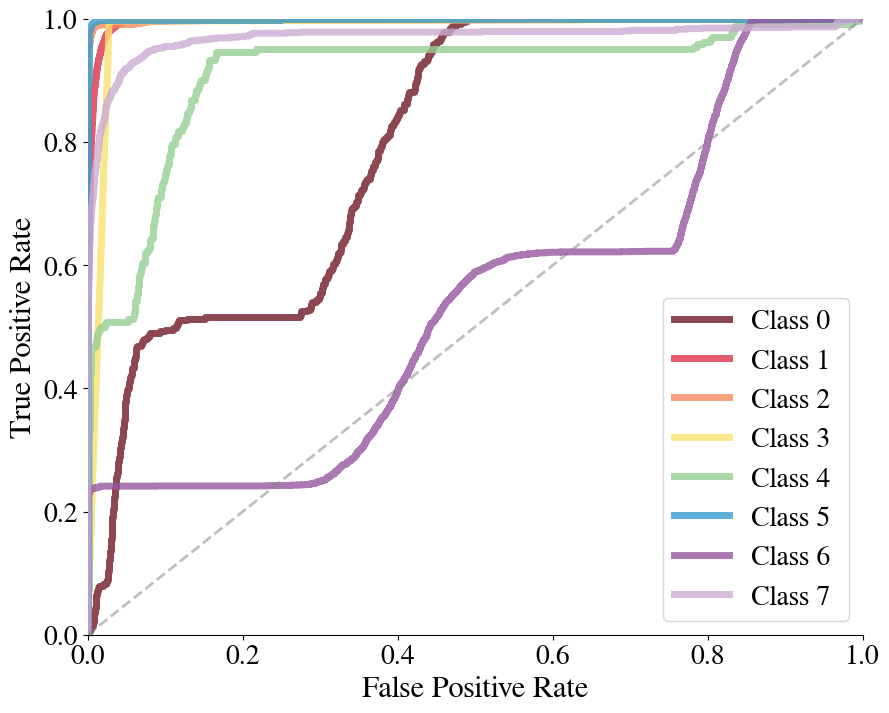

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

In [42]:
# To store ROC curves for each model
all_fpr = []
all_tpr = []
all_roc_auc = []

for i in range(len(Models)):
    Mod = Models[i]
    path_tmp = os.path.join(path, Mod)
    device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tmp_model = Network(1, out_ss, ss=ss, p=0.2, up=0).to(device)
    tmp_model.load_state_dict(torch.load(path_tmp, map_location=device))
    print(f'Model loaded {Mod}')
    tmp_model.eval()
    y_true = []
    y_score = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = tmp_model(inputs, 0)
            y_true.extend(targets.cpu().numpy())
            y_score.extend(outputs.cpu().numpy())

    y_true_np = np.array(y_true)
    y_score_np = np.array(y_score)

    # Binarize the output
    y_true_binarized = label_binarize(y_true_np, classes=np.arange(out_ss))
    n_classes = y_true_binarized.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_true_binarized[:, j], y_score_np[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])

    all_fpr.append(fpr)
    all_tpr.append(tpr)
    all_roc_auc.append(roc_auc)

    colors = ['#6f1926', '#de324c', '#f4895f', '#f8e16f', '#95cf92', '#369acc', '#9656a2', '#cbabd1']

    plt.figure(figsize=(10, 8))
    
    # Define font sizes and styles
    SIZE_DEFAULT = 20
    SIZE_LARGE = 22
    plt.rc("font", family="FreeSerif")  # controls default font
    plt.rc("font", weight="normal")  # controls default font
    plt.rc("font", size=SIZE_DEFAULT)  # controls default text sizes
    plt.rc("axes", titlesize=SIZE_LARGE)  # fontsize of the axes title
    plt.rc("axes", labelsize=SIZE_LARGE)  # fontsize of the x and y labels
    plt.rc("xtick", labelsize=SIZE_DEFAULT)  # fontsize of the tick labels
    plt.rc("ytick", labelsize=SIZE_DEFAULT)  # fontsize of the tick labels
    
    for j in range(n_classes):
        color = colors[j % len(colors)]  # Use modulo to cycle through colors if n_classes > len(colors)
        plt.plot(fpr[j], tpr[j], color=color, lw=5, alpha=0.8,
                label=f'Class {j} ' )

    
    plt.gca().spines["bottom"].set_bounds(0, 1.0)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().spines["top"].set_visible(False)
    plt.plot([0, 1], [0, 1], '--', color='gray', lw=2, alpha=0.5)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    #plt.title(f'{Mod}' )
    plt.legend(loc='lower right' )
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.savefig(f'/home/chiara/DataAUG/Classification/Plots/ROC/{Mod}.png')
    plt.show()



In [43]:
Mod

'DIFF_10.pth'

## Plot mio

In [11]:
#FPR and TPR
from sklearn.metrics import confusion_matrix

def calculate_fpr_tpr_ratio(y_true, y_pred):
    # y_true: true labels
    # y_pred: predicted labels (predicted probabilities or class labels)
    
    # Calcolare la confusion matrix per ottenere i conteggi per ogni classe
    cm = confusion_matrix(y_true, y_pred)
    
    # Numero di classi
    num_classes = len(cm)
    
    # Inizializzare i vettori per FPR e TPR
    fpr = []
    tpr = []
    
    # Calcolare FPR e TPR per ogni classe
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        
        # Calcolare FPR e TPR
        current_fpr = fp / (fp + tn)
        current_tpr = tp / (tp + fn)
        
        # Aggiungere FPR e TPR alla lista
        fpr.append(current_fpr)
        tpr.append(current_tpr)
    
    # Calcolare il rapporto medio di FPR e TPR
    #fpr_tpr_ratio = sum(fpr) / sum(tpr)
    
    return fpr, tpr

def make_dict(FPR, TPR):
    FPR_class = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': [], '6': [], '7': []}
    for i in range(0, len(FPR)):
        FPR_class['0'].append(FPR[i][0]*100)
        FPR_class['1'].append(FPR[i][1]*100)
        FPR_class['2'].append(FPR[i][2]*100)
        FPR_class['3'].append(FPR[i][3]*100)
        FPR_class['4'].append(FPR[i][4]*100)
        FPR_class['5'].append(FPR[i][5]*100)
        FPR_class['6'].append(FPR[i][6]*100)
        FPR_class['7'].append(FPR[i][7]*100)

    TPR_class = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': [], '6': [], '7': []}
    for i in range(0, len(TPR)):
        TPR_class['0'].append(TPR[i][0]*100)
        TPR_class['1'].append(TPR[i][1]*100)
        TPR_class['2'].append(TPR[i][2]*100)
        TPR_class['3'].append(TPR[i][3]*100)
        TPR_class['4'].append(TPR[i][4]*100)
        TPR_class['5'].append(TPR[i][5]*100)
        TPR_class['6'].append(TPR[i][6]*100)
        TPR_class['7'].append(TPR[i][7]*100)
    
    return FPR_class, TPR_class


In [81]:
#Scegli bene Models deve contenere solo i modelli DIFF o GAN in ordine di % 
FPR = []
TPR = []
for i in range(len(Models)):
    Mod = Models[i]
    path_tmp = os.path.join(path, Mod)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tmp_model = Network(1, out_ss, ss=ss, p=0.2, up=0).to(device)
    tmp_model.load_state_dict(torch.load(path_tmp, map_location=device))
    print(f'Model loaded {Mod}')
    tmp_model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = tmp_model(inputs, 0)
            predicted_classes = torch.argmax(outputs, dim=1)

            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predicted_classes.cpu().numpy())


    fpr, tpr = calculate_fpr_tpr_ratio(y_true, y_pred)
    FPR.append(fpr)
    TPR.append(tpr)
    
print("DEAL")
make_dict(FPR, TPR)

Model loaded DIFF_70.pth


Model loaded GAN_70.pth
Model loaded DIFF_90.pth
Model loaded GAN_40.pth
Model loaded 16_with_dropout.pth
Model loaded DIFF_10.pth
Model loaded GAN_90.pth


KeyboardInterrupt: 

In [48]:
#FUNZIONE PLOT
def cal_mse(data,levl):
    data = np.array(data)
    sem = scipy.stats.sem(data)  # Standard error of the mean
    margin_of_error = sem * scipy.stats.t.ppf((1 + levl) / 2., len(data)-1)
    return margin_of_error

def PLOT_Pos(categories, GAN_dat, DIFF_dat, baseline, index, id): 

# Indici delle categorie per il plotting
    x = categories

    fig, ax = plt.subplots(figsize=(10, 6))
    #plt.figure(figsize=(10, 6))


    # Define font sizes and styles
    SIZE_DEFAULT = 20
    SIZE_LARGE = 22
    plt.rc("font", family="FreeSerif")  # controls default font
    plt.rc("font", weight="normal")  # controls default font
    plt.rc("font", size=SIZE_DEFAULT)  # controls default text sizes
    plt.rc("axes", titlesize=SIZE_LARGE)  # fontsize of the axes title
    plt.rc("axes", labelsize=SIZE_LARGE)  # fontsize of the x and y labels
    plt.rc("xtick", labelsize=SIZE_DEFAULT)  # fontsize of the tick labels
    plt.rc("ytick", labelsize=SIZE_DEFAULT)  # fontsize of the tick labels

    # Plot the baseline
    ax.plot(
        [x[0], max(x)],
        [baseline, baseline],
        label=f"Baseline {baseline:.2f}%",
        color="#f77f00",
        linestyle="--",
        linewidth=1,
    )
    
    sem = scipy.stats.sem(0.0364806030388824)  # Standard error of the mean
    margin_of_error = sem * scipy.stats.t.ppf((1 + 0.95) / 2., 7)
    baseline_upper = baseline + margin_of_error
    baseline_lower = baseline - margin_of_error
    ax.fill_between(
    x, baseline_upper, baseline_lower, color='#f77f00', alpha=.15)
    
    
    upp_bound = np.array(GAN_dat) + cal_mse(GAN_dat, 0.95)
    low_bound = np.array(GAN_dat) - cal_mse(GAN_dat, 0.95)

    # Plot each of the main lines

    # Line
    ax.plot(x, GAN_dat, color='#26547C', marker='o', label='GAN Models', linewidth=2)
    ax.fill_between(
    x, upp_bound, low_bound, color='#26547C', alpha=.15)

    # Line
    upp_bound = np.array(DIFF_dat) + cal_mse(DIFF_dat, 0.95)
    low_bound = np.array(DIFF_dat) - cal_mse(DIFF_dat, 0.95)
    ax.plot(x, DIFF_dat, color='#EF476F', marker='x', label='DDPM Models', linewidth=2)
    ax.fill_between(
    x, upp_bound, low_bound, color='#EF476F', alpha=.15)

    # Hide the all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # Only show ticks on the left and bottom spines
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")
    ax.spines["bottom"].set_bounds(min(x), max(x))



    # Titolo del grafico
    ax.set_title(' ')

    ax.legend()

    # -------------------BEGIN-CHANGES------------------------
    ax.set_xlabel("Percentual of synthetic data (%)")  # Enable TeX typesetting of the superscript
    # --------------------END CHANGES-------------------------
    ax.set_ylabel(f"Average {index} ")
    plt.savefig(f'/home/chiara/DataAUG/Classification/Plots/{index}_{id}.png')

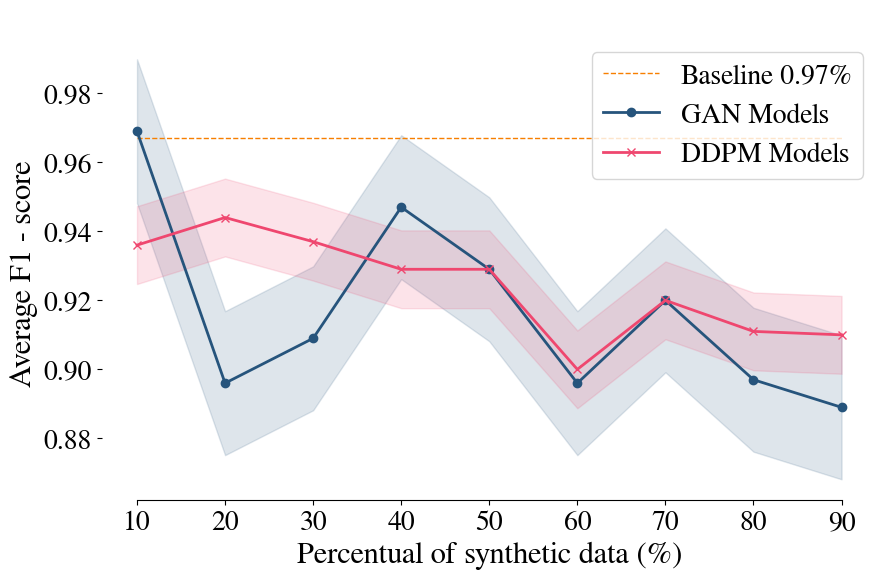

In [49]:
categories = [10, 20, 30, 40, 50, 60, 70, 80,90]
GAN_dat = [ 0.969,
0.896,
0.909,
0.947,
0.929,
0.896,
0.920,
0.897,
0.889]
DIFF_dat = [0.936,
0.944,
0.937,
0.929,
0.929,
0.9,
0.920,
0.911,
0.910]
baseline = 0.967 # 1 1 0.98 0.91 1 0.54 0.97
PLOT_Pos(categories, GAN_dat, DIFF_dat, baseline, 'F1 - score', 0)

In [53]:
import numpy as np

# Calculate the mean of the given list of numbers
mean_value = np.mean([
    0.936,
    0.944,
    0.937,
    0.929,
    0.929,
    0.9,
    0.920,
    0.911,
    0.910
])

print(mean_value)


# Calculate the mean of the given list of numbers
mean_value = np.mean([ 0.969,
0.896,
0.909,
0.947,
0.929,
0.896,
0.920,
0.897,
0.889])

print(mean_value)
print(0.924-
0.916888888888889)

0.924
0.916888888888889
0.007111111111111068


In [ ]:
# Perform inference using the diffusion model
prompt = "a photo of a cat"
image = pipe(prompt).images[0]

# Display the generated image
image.show()

In [4]:
from diffusers import DiffusionPipeline
import torch

pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0",
                                         torch_dtype=torch.float16, 
                                         use_safetensors=True, 
                                         variant="fp16")
pipe.to("cuda")

prompt = "An astronaut riding a green horse"

images = pipe(prompt=prompt).images[0]
image
import torch
torch.cuda.empty_cache()

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.35it/s]


In [6]:
pipe.to("cuda")


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 

In [7]:

prompt = "An astronaut riding a green horse"

images = pipe(prompt=prompt).images[0]
image


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument index in method wrapper_CUDA__index_select)

In [3]:
import torch
torch.cuda.empty_cache()